In [1]:
!pip install -q kaggle

In [ ]:
import os
import json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username":"",
    "key": ""
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [4]:
!mkdir -p /content/data

!kaggle datasets download \
    -d salader/dogsvscats \
    -p /content/data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:09<00:00, 115MB/s]



In [5]:
!find /content/data -maxdepth 3 -type d

/content/data
/content/data/catsvsdogs
/content/data/catsvsdogs/test
/content/data/catsvsdogs/test/cats
/content/data/catsvsdogs/test/dogs
/content/data/catsvsdogs/train
/content/data/catsvsdogs/train/cats
/content/data/catsvsdogs/train/dogs
/content/data/test
/content/data/test/cats
/content/data/test/dogs
/content/data/train
/content/data/train/cats
/content/data/train/dogs


In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [7]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [9]:
conv_base.trainable = False

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [12]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/data/catsvsdogs/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/data/catsvsdogs/test',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [13]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 269ms/step - accuracy: 0.8673 - loss: 0.3015 - val_accuracy: 0.9114 - val_loss: 0.2124
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 260ms/step - accuracy: 0.8961 - loss: 0.2388 - val_accuracy: 0.9000 - val_loss: 0.2222
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 260ms/step - accuracy: 0.9054 - loss: 0.2186 - val_accuracy: 0.9130 - val_loss: 0.1984
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.9097 - loss: 0.2143 - val_accuracy: 0.9162 - val_loss: 0.1942
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 257ms/step - accuracy: 0.9110 - loss: 0.2050 - val_accuracy: 0.9144 - val_loss: 0.2028
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 258ms/step - accuracy: 0.9188 - loss: 0.1925 - val_accuracy: 0.9146 - val_loss: 0.2058
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9219 - loss: 0.1827 - val_accuracy: 0.9182 - val_loss: 0.1975
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 261ms/step - accuracy: 0.9265 -

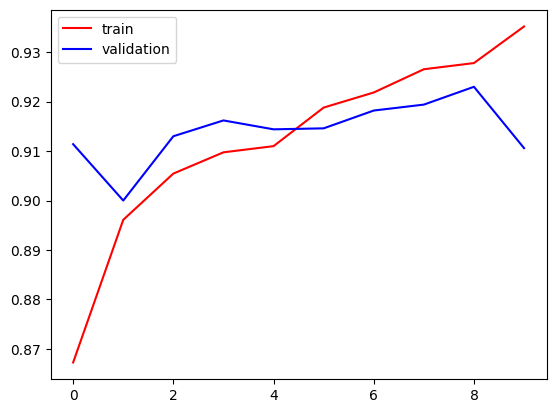

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

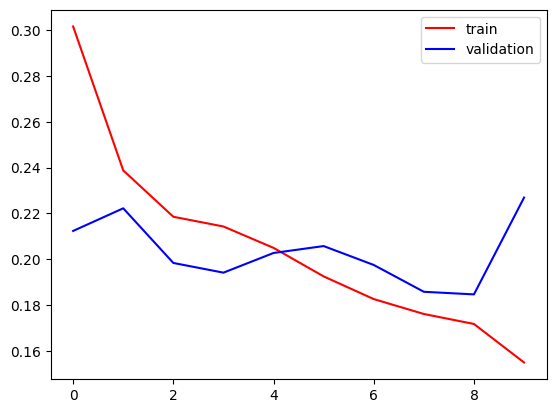

In [17]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()